# **ML Project**

# **Load the Heart Disease Cleveland Dataset**

In [90]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/heart-disease-cleveland.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


#**Data Prepration**

## **Data seperation as x and y**

In [92]:
y = df[' diagnosis']
y

,diagnosis
0,0
1,2
2,1
3,0
4,0
...,...
298,1
299,2
300,3
301,1


## **Extract Feature Variables**

In [93]:
x = df.drop(' diagnosis', axis=1)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


# **Splitting the data set as training and testing with values as 75% and 25% respectively**

In [95]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=100, stratify=y)

In [96]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
59,51,1,1,125,213,0,2,125,1,1.4,1,1.0,3.0
219,59,1,4,138,271,0,2,182,0,0.0,1,0.0,3.0
175,57,1,4,152,274,0,0,88,1,1.2,2,1.0,7.0
198,50,0,2,120,244,0,0,162,0,1.1,1,0.0,3.0
279,58,0,4,130,197,0,0,131,0,0.6,2,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,55,1,4,160,289,0,2,145,1,0.8,2,1.0,7.0
105,54,1,2,108,309,0,0,156,0,0.0,1,0.0,7.0
186,42,1,3,120,240,1,0,194,0,0.8,3,0.0,7.0
291,55,0,2,132,342,0,0,166,0,1.2,1,0.0,3.0


### **Check Data Types**

In [97]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
109,39,1,4,118,219,0,0,140,0,1.2,2,0.0,7.0
47,50,1,4,150,243,0,2,128,0,2.6,2,0.0,7.0
289,56,1,2,120,240,0,0,169,0,0.0,3,0.0,3.0
149,60,0,3,102,318,0,0,160,0,0.0,1,1.0,3.0
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,51,1,4,140,299,0,0,173,1,1.6,1,0.0,7.0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7.0
60,51,0,4,130,305,0,0,142,1,1.2,2,0.0,7.0
11,56,0,2,140,294,0,2,153,0,1.3,2,0.0,3.0


In [98]:
x_train.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### **Handle Missing Values**

### **Step 1: Remove Rows**

In [110]:
x_train = x_train.dropna(subset=[" ca", " thal"])
y_train = y_train.loc[x_train.index]

### **Step 2: Verify Cleaning**

In [111]:
x_train.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### **Step 3: Convert to Numeric**

In [112]:
x_train[" ca"] = pd.to_numeric(x_train[" ca"], errors="coerce")
x_train[" thal"] = pd.to_numeric(x_train[" thal"], errors="coerce")

x_test[" ca"] = pd.to_numeric(x_test[" ca"], errors="coerce")
x_test[" thal"] = pd.to_numeric(x_test[" thal"], errors="coerce")

### **Check Data Types**

In [113]:
x_train.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [114]:
x_test.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### **Feature Scaling - Standardization**

In [115]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [116]:
x_train_sc = sc.fit_transform(x_train)

In [117]:
x_test_sc = sc.transform(x_test)

# **Model Training**
## **Train Logistic Regression Classifier**

In [118]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_sc, y_train)

LogisticRegression()

## **Generate Predictions**

In [119]:
y_pred = lr.predict(x_test_sc)
acc_1 = print(accuracy_score(y_test, y_pred))

0.6052631578947368


# **Data Analysis**

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

### **Visualization 1: Histogram indicating amount against Age distribution**

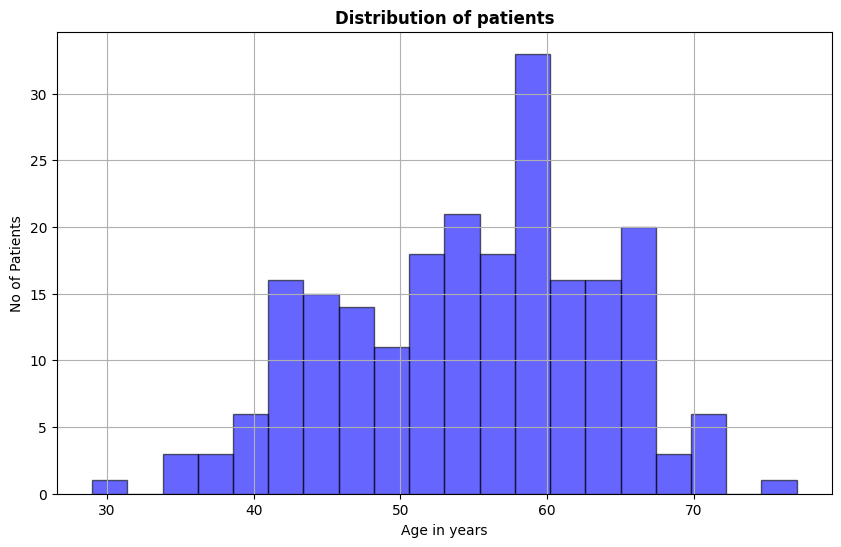

In [121]:
plt.figure(figsize=(10,6))
plt.hist(x_train['age'], bins=20, color='blue', edgecolor='black', alpha=0.6)
plt.xlabel('Age in years')
plt.ylabel('No of Patients')
plt.title('Distribution of patients',fontweight='bold')
plt.grid(True)
plt.show()

### **Visualization 2:Pie Chart indicating the split between genders**

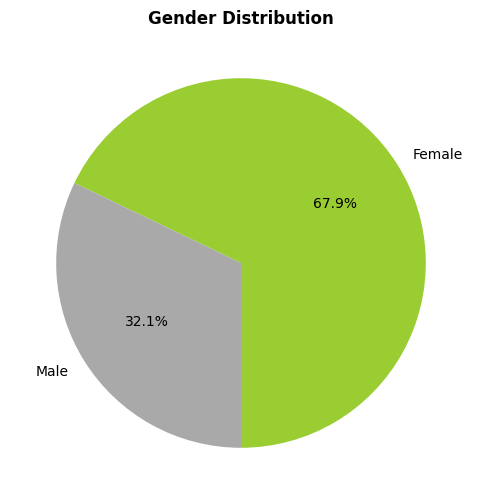

In [122]:
gender_count = x_train[' sex'].value_counts()
plt.figure(figsize=(10,6))
plt.pie(gender_count, labels = ['Female', 'Male'], colors = ['yellowgreen', 'darkgrey'], autopct='%1.1f%%', startangle=270)
plt.title('Gender Distribution',fontweight='bold')
plt.show()

### **Visualization 3: Disease Severity Distribution Bar Chart**

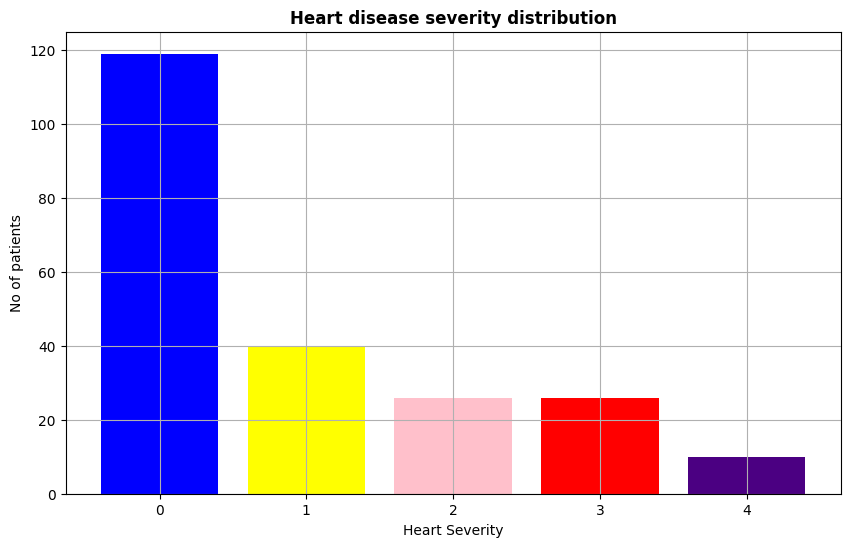

In [123]:
heart_severity = y_train.value_counts().sort_index()
colors=['blue','yellow','pink','red','indigo']
plt.figure(figsize=(10,6))
plt.bar(heart_severity.index, heart_severity.values, color=colors)
plt.xticks([0,1,2,3,4])
plt.xlabel('Heart Severity')
plt.ylabel('No of patients')
plt.title('Heart disease severity distribution',fontweight='bold')
plt.grid(True)
plt.show()

### **Visualization 4: Disease Severity Distribution by Age Group**

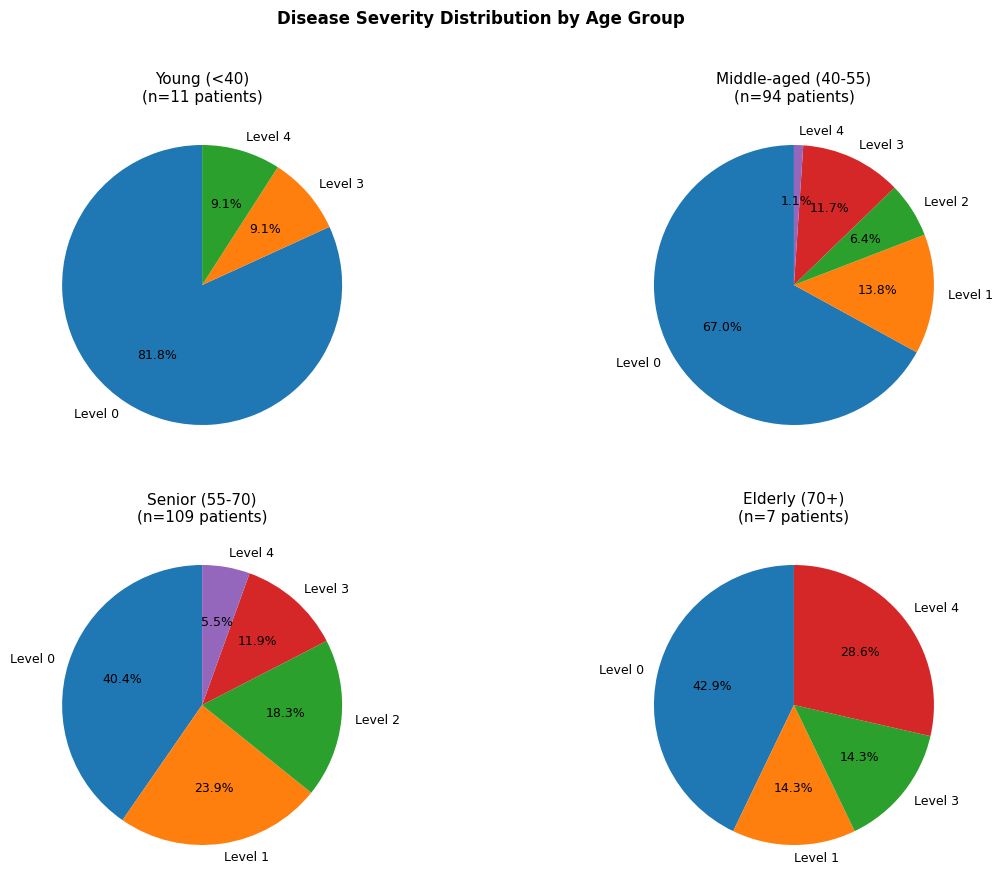

In [124]:
age_groups = [
    (x_train['age'] < 40, 'Young (<40)'),
    ((x_train['age'] >= 40) & (x_train['age'] < 55), 'Middle-aged (40-55)'),
    ((x_train['age'] >= 55) & (x_train['age'] < 70), 'Senior (55-70)'),
    (x_train['age'] >= 70, 'Elderly (70+)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (condition, label) in enumerate(age_groups):
    disease_counts = y_train[condition].value_counts().sort_index()

    axes[idx].pie(disease_counts.values,
                  labels=[f'Level {i}' for i in disease_counts.index],
                  autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
    axes[idx].set_title(f'{label}\n(n={condition.sum()} patients)',
                        fontsize=11, )

fig.suptitle('Disease Severity Distribution by Age Group',fontweight='bold')
plt.show()


# **Testing various Models against the dataset**

## **Random Forest**

In [125]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=100)
rf.fit(x_train_sc, y_train)

from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix
y_pred = rf.predict(x_test_sc)
acc_2 = print(accuracy_score(y_test, y_pred))

0.5657894736842105


## **Gradient Boosting**

In [126]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=100)
gb.fit(x_train_sc, y_train)

y_pred = gb.predict(x_test_sc)
acc_3 = print(accuracy_score(y_test, y_pred))

0.5394736842105263


## **XG-Boosting**

In [127]:
from xgboost import XGBClassifier
xb = XGBClassifier(random_state=100)
xb.fit(x_train_sc, y_train)

y_pred = xb.predict(x_test_sc)
acc_4 = print(accuracy_score(y_test, y_pred))

0.5526315789473685


## **Support Vector Machine**

In [128]:
from sklearn.svm import SVC
svc =SVC(random_state=100)
svc.fit(x_train_sc, y_train)

y_pred = svc.predict(x_test_sc)
acc_5 = print(accuracy_score(y_test, y_pred))

0.6578947368421053


## **Neural Network using Multi-Layer Perceptron**

In [129]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=100, max_iter=1000)
mlp.fit(x_train_sc, y_train)

y_pred = mlp.predict(x_test_sc)
acc_6 = print(accuracy_score(y_test, y_pred))

0.5921052631578947


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# **Model Evaluation Metrics Analysis**

## **Visualization 5: Accuracy comparision between all the models**

Logistic Regression: 0.6052631578947368
Random Forest: 0.5657894736842105
Gradient Boosting: 0.5394736842105263
XBoosting: 0.5526315789473685
SVM: 0.6578947368421053
Neural Network: 0.5921052631578947


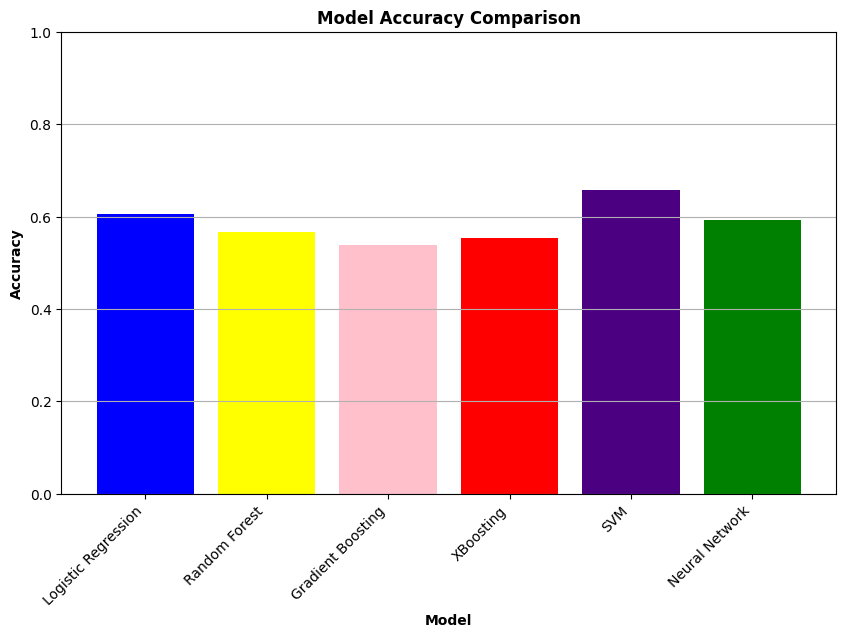

In [130]:
models = {'Logistic Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb, 'XBoosting': xb, 'SVM': svc, 'Neural Network': mlp}
accuracies = []

for name, model in models.items():
    y_pred = model.predict(x_test_sc)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{name}: {acc}")

plt.figure(figsize=(10, 6))
plt.bar(list(models.keys()), accuracies, color=['blue', 'yellow', 'pink', 'red', 'indigo', 'green'])
plt.ylabel('Accuracy', fontweight='bold')
plt.xlabel('Model',fontweight='bold')
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1])
plt.grid(axis='y')
plt.show()



## **Visualization 6: Performance Comaprision between Models**

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


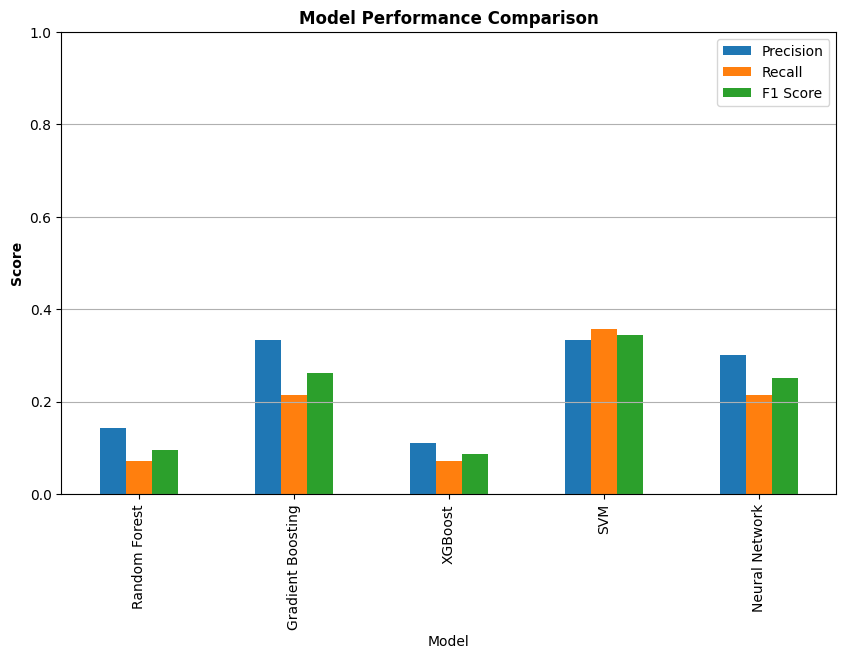

In [131]:
reports = {}

y_pred_rf = rf.predict(x_test_sc)
reports['Random Forest'] = classification_report(y_test, y_pred_rf, output_dict=True)

y_pred_gb = gb.predict(x_test_sc)
reports['Gradient Boosting'] = classification_report(y_test, y_pred_gb, output_dict=True)

y_pred_xb = xb.predict(x_test_sc)
reports['XGBoost'] = classification_report(y_test, y_pred_xb, output_dict=True)

y_pred_svc = svc.predict(x_test_sc)
reports['SVM'] = classification_report(y_test, y_pred_svc, output_dict=True)

y_pred_mlp = mlp.predict(x_test_sc)
reports['Neural Network'] = classification_report(y_test, y_pred_mlp, output_dict=True)

metrics_data = []

for model, report in reports.items():
    metrics_data.append({
        'Model': model,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1 Score': report['1']['f1-score']
    })

metrics_df = pd.DataFrame(metrics_data)

metrics_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y')
plt.show()
